In [6]:
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten
import matplotlib.pyplot as plt
import numpy as np

In [7]:
df= datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 42s 0us/step


c:\Users\sharm\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


In [8]:
df

((array([[[[ 59,  62,  63],
           [ 43,  46,  45],
           [ 50,  48,  43],
           ...,
           [158, 132, 108],
           [152, 125, 102],
           [148, 124, 103]],
  
          [[ 16,  20,  20],
           [  0,   0,   0],
           [ 18,   8,   0],
           ...,
           [123,  88,  55],
           [119,  83,  50],
           [122,  87,  57]],
  
          [[ 25,  24,  21],
           [ 16,   7,   0],
           [ 49,  27,   8],
           ...,
           [118,  84,  50],
           [120,  84,  50],
           [109,  73,  42]],
  
          ...,
  
          [[208, 170,  96],
           [201, 153,  34],
           [198, 161,  26],
           ...,
           [160, 133,  70],
           [ 56,  31,   7],
           [ 53,  34,  20]],
  
          [[180, 139,  96],
           [173, 123,  42],
           [186, 144,  30],
           ...,
           [184, 148,  94],
           [ 97,  62,  34],
           [ 83,  53,  34]],
  
          [[177, 144, 116],
           [16

In [9]:
(x_train,y_train),(x_test,y_test)= df

In [10]:
x_train.shape

(50000, 32, 32, 3)

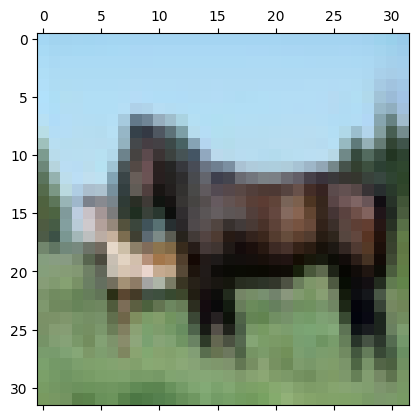

In [27]:
# plt.figure(figsize=(1,2))
plt.matshow(x_train[12])

In [12]:
x_train[250]

array([[[129, 145, 145],
        [136, 151, 151],
        [141, 157, 157],
        ...,
        [ 83,  94,  96],
        [ 83,  94,  96],
        [ 86,  97,  99]],

       [[113, 127, 128],
        [118, 131, 132],
        [123, 136, 137],
        ...,
        [ 88,  99, 101],
        [ 88,  99, 101],
        [ 90, 101, 103]],

       [[100, 111, 113],
        [104, 116, 117],
        [109, 120, 122],
        ...,
        [ 93, 104, 106],
        [ 93, 104, 106],
        [ 95, 106, 108]],

       ...,

       [[133, 137, 136],
        [131, 135, 134],
        [130, 134, 133],
        ...,
        [126, 135, 134],
        [126, 135, 134],
        [127, 136, 135]],

       [[125, 129, 128],
        [122, 126, 125],
        [122, 126, 125],
        ...,
        [120, 129, 128],
        [120, 129, 128],
        [120, 129, 128]],

       [[117, 121, 120],
        [114, 118, 117],
        [114, 118, 117],
        ...,
        [113, 122, 121],
        [113, 122, 121],
        [113, 122, 121]]

In [13]:
y_train[250]

array([1], dtype=uint8)

In [14]:
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [15]:
x_train[15]

array([[[100, 168, 231],
        [100, 168, 229],
        [101, 167, 230],
        ...,
        [ 95, 165, 231],
        [ 94, 165, 228],
        [ 95, 167, 229]],

       [[103, 170, 230],
        [103, 168, 228],
        [104, 168, 226],
        ...,
        [ 97, 167, 229],
        [ 97, 166, 227],
        [ 97, 168, 229]],

       [[107, 174, 233],
        [106, 172, 230],
        [106, 173, 229],
        ...,
        [100, 170, 230],
        [100, 170, 230],
        [101, 172, 232]],

       ...,

       [[165, 178, 177],
        [159, 170, 167],
        [167, 177, 170],
        ...,
        [ 75, 117, 154],
        [ 75, 120, 157],
        [ 72, 120, 158]],

       [[158, 174, 172],
        [173, 186, 182],
        [182, 193, 188],
        ...,
        [ 76, 119, 154],
        [ 75, 119, 153],
        [ 77, 121, 154]],

       [[161, 176, 174],
        [162, 176, 172],
        [160, 171, 169],
        ...,
        [ 98, 137, 167],
        [129, 160, 183],
        [162, 185, 202]]

In [16]:
y_train[15]

array([9], dtype=uint8)

In [17]:
y_train= y_train.reshape(-1,)

In [18]:
y_train.ndim

1

In [19]:
# model
model = models.Sequential([
    layers.Conv2D(filters=32, kernel_size=(3,3),activation='relu',input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(filters=64, kernel_size=(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(10, activation='softmax')  # [.2,.3,.7,.9,.2,.3,.8]
])

c:\Users\sharm\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [21]:
model.fit(x_train, y_train, epochs=10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.3953 - loss: 1.7880
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.5476 - loss: 1.2789
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.6104 - loss: 1.1108
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.6549 - loss: 0.9994
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.6800 - loss: 0.9271
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.7054 - loss: 0.8568
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.7277 - loss: 0.7938
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.7470 - loss: 0.7364
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.7671 - loss: 0.6818
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.7825 - loss: 0.6322


In [22]:
y_pred = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [23]:
y_pred[20]

array([8.6829755e-03, 1.5307500e-04, 8.6658545e-02, 1.4510646e-01,
       3.8219813e-01, 8.5559450e-03, 1.2109530e-03, 3.6443314e-01,
       5.3401454e-05, 2.9473570e-03], dtype=float32)

In [24]:
classes[np.argmax(y_pred[20])]

'deer'

In [25]:
y_test[20]

array([7], dtype=uint8)

In [26]:
classes[y_test[12][0]]

'dog'